In [1]:
# Parameters
TRAIN_DATA_NAME = "sonar"
TEST_DATA_NAME = "sonar"


# 🔬 Test Model - Sonar Returns Classification
**Bài toán:** Binary Classification – Mine (M) vs Rock (R)  
**Mục đích:** Load model đã train → test trên bộ dữ liệu tùy chọn

## Bước 10: Khởi tạo thí nghiệm Test

In [2]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
from datetime import datetime
from openpyxl import load_workbook
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

# ── Tham số thực nghiệm ─────────────────────────────────
# ============================================================
# TRAIN_DATA_NAME : tên data đã dùng để TRAIN (để biết load model nào)
# TEST_DATA_NAME  : tên data muốn TEST (có thể khác TRAIN)
TRAIN_DATA_NAME = 'sonar'  # tên data đã dùng để TRAIN → load model từ model/{TRAIN_DATA_NAME}/
TEST_DATA_NAME  = 'sonar'  # tên data muốn TEST → bắt buộc đã được EDA rồi
# ============================================================

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) \
            if os.path.basename(os.getcwd()) == 'prj' else os.getcwd()
EXP_DIR   = os.path.join(BASE_DIR, 'exps_')
MODEL_DIR = os.path.join(BASE_DIR, 'model', TRAIN_DATA_NAME)

LOG_NAME = f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_log.xlsx'
TEST_LOG = os.path.join(EXP_DIR, LOG_NAME)

TEST_FILES = {
    'raw'     : os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_raw.csv'),
    'minmax'  : os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_minmax.csv'),
    'standard': os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_test_standard.csv'),
}

COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   Thời gian       : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   TRAIN_DATA_NAME : {TRAIN_DATA_NAME}  → load model từ model/{TRAIN_DATA_NAME}/')
print(f'   TEST_DATA_NAME  : {TEST_DATA_NAME}   → đọc test từ exps_/{TEST_DATA_NAME}_test_*.csv')
print(f'   Kết quả lưu tại : {LOG_NAME}')

✅ Khai báo thư viện và tham số xong!
   Thời gian       : 2026-03-14 23:50:54
   TRAIN_DATA_NAME : sonar  → load model từ model/sonar/
   TEST_DATA_NAME  : sonar   → đọc test từ exps_/sonar_test_*.csv
   Kết quả lưu tại : sonar__test_sonar_log.xlsx


## Bước 11: Kiểm tra điều kiện trước khi test

In [3]:
# Kiểm tra 3 điều kiện:
# 1. Folder model/{TRAIN_DATA_NAME}/ tồn tại và có file .pkl
# 2. File EDA của bộ TEST tồn tại (đảm bảo đã EDA)
# 3. Cả 3 file test CSV của bộ TEST tồn tại

errors = []
pkl_count = 0

# Kiểm tra model
if not os.path.isdir(MODEL_DIR):
    errors.append(f'[THIẾU MODEL FOLDER] model/{TRAIN_DATA_NAME}/ chưa tồn tại')
else:
    pkl_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl')]
    pkl_count = len(pkl_files)
    if pkl_count == 0:
        errors.append(f'[THIẾU MODEL] Không có file .pkl nào trong model/{TRAIN_DATA_NAME}/')

# Kiểm tra EDA của bộ test
test_eda_log = os.path.join(EXP_DIR, f'{TEST_DATA_NAME}_eda_log.xlsx')
if not os.path.exists(test_eda_log):
    errors.append(f'[CHƯA EDA TEST DATA] {os.path.basename(test_eda_log)} chưa tồn tại')

# Kiểm tra file test CSV
for sn, fp in TEST_FILES.items():
    if not os.path.exists(fp):
        errors.append(f'[THIẾU CSV] {os.path.basename(fp)}')

if errors:
    print('=' * 65)
    print('❌ TỪ CHỐI TEST – Các điều kiện chưa đủ!')
    print('=' * 65)
    for e in errors:
        print(f'   {e}')
    print()
    if any('MODEL' in e for e in errors):
        print(f'   → Hãy chạy 02_train.ipynb  (TRAIN_DATA_NAME = {TRAIN_DATA_NAME!r})')
        print(f'     hoặc: python bin/run_train.py {TRAIN_DATA_NAME}')
    if any('EDA' in e or 'CSV' in e for e in errors):
        print(f'   → Hãy chạy 01_eda.ipynb    (DATA_NAME = {TEST_DATA_NAME!r})')
        print(f'     hoặc: python bin/run_eda.py {TEST_DATA_NAME}')
    print('=' * 65)
    raise SystemExit('Điều kiện chưa đủ – dừng lại!')
else:
    print('=' * 65)
    print('✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!')
    print('=' * 65)
    print(f'   [OK] Model folder  : model/{TRAIN_DATA_NAME}/  ({pkl_count} files)')
    print(f'   [OK] Test EDA log  : {os.path.basename(test_eda_log)}')
    for fp in TEST_FILES.values():
        print(f'   [OK] {os.path.basename(fp)}')
    print('=' * 65)

✅ TẤT CẢ ĐIỀU KIỆN THỎA MÃN – Sẵn sàng test!
   [OK] Model folder  : model/sonar/  (37 files)
   [OK] Test EDA log  : sonar_eda_log.xlsx
   [OK] sonar_test_raw.csv
   [OK] sonar_test_minmax.csv
   [OK] sonar_test_standard.csv


## Bước 12: Load model đã train

In [4]:
all_models = {}
for fname in sorted(pkl_files):
    if '__best_model' in fname:
        continue
    parts = fname.replace('.pkl','').split('__')
    if len(parts) < 3:
        continue
    scaler     = parts[1]
    model_name = parts[2].replace('_',' ')
    with open(os.path.join(MODEL_DIR, fname), 'rb') as f:
        est = pickle.load(f)
    if scaler not in all_models:
        all_models[scaler] = {}
    all_models[scaler][model_name] = est

print(f'=== MODEL ĐÃ LOAD TỪ model/{TRAIN_DATA_NAME}/ ===')
for sn, models in all_models.items():
    print(f'   [{sn:8s}] {len(models)} models')
print(f'✅ Tổng cộng: {sum(len(v) for v in all_models.values())} models')

=== MODEL ĐÃ LOAD TỪ model/sonar/ ===
   [minmax  ] 12 models
   [raw     ] 12 models
   [standard] 12 models
✅ Tổng cộng: 36 models


## Bước 13: Dữ liệu kiểm nghiệm

In [5]:
def load_test(path):
    df = pd.read_csv(path)
    return df.iloc[:, :-1].values, df.iloc[:, -1].values

print('=== KIỂM TRA FILE TEST ===')
for sn, path in TEST_FILES.items():
    X, y = load_test(path)
    print(f'[{sn:8s}] {os.path.basename(path)} | Shape: {X.shape} | Classes: {np.unique(y)}')
print(f'\n✅ Dữ liệu test sẵn sàng!')

=== KIỂM TRA FILE TEST ===


[raw     ] sonar_test_raw.csv | Shape: (63, 60) | Classes: ['M' 'R']
[minmax  ] sonar_test_minmax.csv | Shape: (63, 60) | Classes: ['M' 'R']
[standard] sonar_test_standard.csv | Shape: (63, 60) | Classes: ['M' 'R']

✅ Dữ liệu test sẵn sàng!


## Bước 14: Đánh giá model trên tập Test

In [6]:
test_results = []
best_overall = {'acc': 0, 'model': None, 'name': '', 'scaler': ''}
pos_label    = None

for sn in ['raw', 'minmax', 'standard']:
    if sn not in all_models:
        continue
    X_test, y_test = load_test(TEST_FILES[sn])
    if pos_label is None:
        pos_label = sorted(np.unique(y_test))[0]  # 'M' = positive class

    print(f'\n📊 [{sn.upper()}] Test trên {TEST_DATA_NAME}:')
    print(f'  {"Model":<25} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6}')
    print('  ' + '-' * 60)

    for model_name, est in all_models[sn].items():
        y_pred = est.predict(X_test)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        rec  = recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        f1   = f1_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
        # AUC: tìm đúng cột xác suất theo pos_label
        if hasattr(est, 'predict_proba'):
            pos_idx = list(est.classes_).index(pos_label)
            y_prob  = est.predict_proba(X_test)[:, pos_idx]
            auc     = roc_auc_score(y_test == pos_label, y_prob)
        else:
            auc = np.nan
        test_results.append({
            'Scaler'   : sn,
            'Model'    : model_name,
            'Accuracy' : round(acc,  2),
            'Precision': round(prec, 2),
            'Recall'   : round(rec,  2),
            'F1-Score' : round(f1,   2),
            'AUC'      : round(auc,  2) if not np.isnan(auc) else 'N/A',
        })
        auc_str = f'{auc:6.2f}' if not np.isnan(auc) else '   N/A'
        print(f'  {model_name:<25} {acc:6.2f} {prec:6.2f} {rec:6.2f} {f1:6.2f} {auc_str}')
        if acc > best_overall['acc']:
            best_overall = {'acc': acc, 'model': est, 'name': model_name, 'scaler': sn}

df_test = pd.DataFrame(test_results)
print(f'\n🏆 Best: {best_overall["name"]} [{best_overall["scaler"]}] | Acc = {best_overall["acc"]:.2f}')



📊 [RAW] Test trên sonar:
  Model                        Acc   Prec    Rec     F1    AUC
  ------------------------------------------------------------
  AdaBoost                    0.78   0.73   0.94   0.82   0.91
  Decision Tree               0.62   0.64   0.68   0.66   0.61
  Gradient Boosting           0.81   0.74   1.00   0.85   0.95
  LDA                         0.73   0.72   0.82   0.77   0.80
  Logistic Reg.               0.76   0.76   0.82   0.79   0.83
  MLP                         0.83   0.79   0.91   0.85   0.89
  Naive Bayes                 0.62   0.73   0.47   0.57   0.69
  Random Forest               0.86   0.80   0.97   0.88   0.94


  Random Forest tuned         0.84   0.79   0.97   0.87   0.91
  SVM                         0.81   0.76   0.94   0.84   0.88
  SVM tuned                   0.84   0.82   0.91   0.86   0.92


  kNN                         0.73   0.72   0.82   0.77   0.78

📊 [MINMAX] Test trên sonar:
  Model                        Acc   Prec    Rec     F1    AUC
  ------------------------------------------------------------
  AdaBoost                    0.78   0.73   0.94   0.82   0.91
  Decision Tree               0.62   0.64   0.68   0.66   0.61
  Gradient Boosting           0.81   0.74   1.00   0.85   0.95
  LDA                         0.73   0.72   0.82   0.77   0.80
  Logistic Reg.               0.75   0.75   0.79   0.77   0.83
  MLP                         0.79   0.78   0.85   0.82   0.88
  Naive Bayes                 0.62   0.73   0.47   0.57   0.69
  Random Forest               0.86   0.80   0.97   0.88   0.94
  Random Forest tuned         0.84   0.79   0.97   0.87   0.91
  SVM                         0.83   0.81   0.88   0.85   0.90
  SVM tuned                   0.89   0.89   0.91   0.90   0.93
  kNN                         0.78   0.76   0.85   0.81   0.84

📊 [STANDARD] Test trên so

  AdaBoost                    0.78   0.73   0.94   0.82   0.91
  Decision Tree               0.62   0.64   0.68   0.66   0.61
  Gradient Boosting           0.81   0.74   1.00   0.85   0.95
  LDA                         0.73   0.72   0.82   0.77   0.80
  Logistic Reg.               0.75   0.76   0.76   0.76   0.84
  MLP                         0.81   0.81   0.85   0.83   0.93
  Naive Bayes                 0.62   0.73   0.47   0.57   0.69
  Random Forest               0.86   0.80   0.97   0.88   0.94
  Random Forest tuned         0.84   0.79   0.97   0.87   0.91
  SVM                         0.79   0.77   0.88   0.82   0.90
  SVM tuned                   0.90   0.89   0.94   0.91   0.93
  kNN                         0.73   0.71   0.85   0.77   0.86

🏆 Best: SVM tuned [standard] | Acc = 0.90


## Bước 15: Phân tích Top 2 model theo từng tiêu chí

In [7]:
# Đề yêu cầu: tìm 2 model tốt nhất theo từng tiêu chí
# và nhận xét chúng có giống nhau không
best_sn_for_top2 = best_overall['scaler']
df_best = df_test[df_test['Scaler'] == best_sn_for_top2].copy()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
print(f'=== TOP 2 MODEL THEO TỪNG TIÊU CHÍ (Scaler: {best_sn_for_top2.upper()}) ===')
print(f'  {"Tiêu chí":<12} {"#1 Model":<28} {"Score":>6}  {"#2 Model":<28} {"Score":>6}')
print('  ' + '-' * 90)

top2_summary = []
for metric in metrics:
    df_num = df_best[df_best[metric] != 'N/A'].copy()
    df_num[metric] = df_num[metric].astype(float)
    top2 = df_num.nlargest(2, metric)[['Model', metric]].values.tolist()
    if len(top2) >= 2:
        r1, r2 = top2[0], top2[1]
        print(f'  {metric:<12} {r1[0]:<28} {r1[1]:>6.2f}  {r2[0]:<28} {r2[1]:>6.2f}')
        top2_summary.append({'Tiêu chí': metric, 'Top1': r1[0], 'Top1 Score': r1[1],
                                                  'Top2': r2[0], 'Top2 Score': r2[1]})

print()
top1_models = [r['Top1'] for r in top2_summary]
unique_top1 = set(top1_models)
print('Nhận xét:')
if len(unique_top1) == 1:
    print(f'  → Top 1 theo TẤT CẢ tiêu chí đều là: {list(unique_top1)[0]}')
    print(f'  → Model này vượt trội trên mọi tiêu chí đánh giá')
else:
    print(f'  → Top 1 KHÁC NHAU tùy theo tiêu chí:')
    for r in top2_summary:
        print(f'     {r["Tiêu chí"]:<12} → {r["Top1"]} ({r["Top1 Score"]:.2f})')
    print(f'  → Không có model nào tốt nhất trên tất cả tiêu chí')
    print(f'  → Tùy mục đích sử dụng mà chọn model phù hợp')


=== TOP 2 MODEL THEO TỪNG TIÊU CHÍ (Scaler: STANDARD) ===
  Tiêu chí     #1 Model                      Score  #2 Model                      Score
  ------------------------------------------------------------------------------------------
  Accuracy     SVM tuned                      0.90  Random Forest                  0.86
  Precision    SVM tuned                      0.89  MLP                            0.81
  Recall       Gradient Boosting              1.00  Random Forest                  0.97
  F1-Score     SVM tuned                      0.91  Random Forest                  0.88
  AUC          Gradient Boosting              0.95  Random Forest                  0.94

Nhận xét:
  → Top 1 KHÁC NHAU tùy theo tiêu chí:
     Accuracy     → SVM tuned (0.90)
     Precision    → SVM tuned (0.89)
     Recall       → Gradient Boosting (1.00)
     F1-Score     → SVM tuned (0.91)
     AUC          → Gradient Boosting (0.95)
  → Không có model nào tốt nhất trên tất cả tiêu chí
  → Tùy mục đích 

## Bước 16: Biểu đồ Test Accuracy

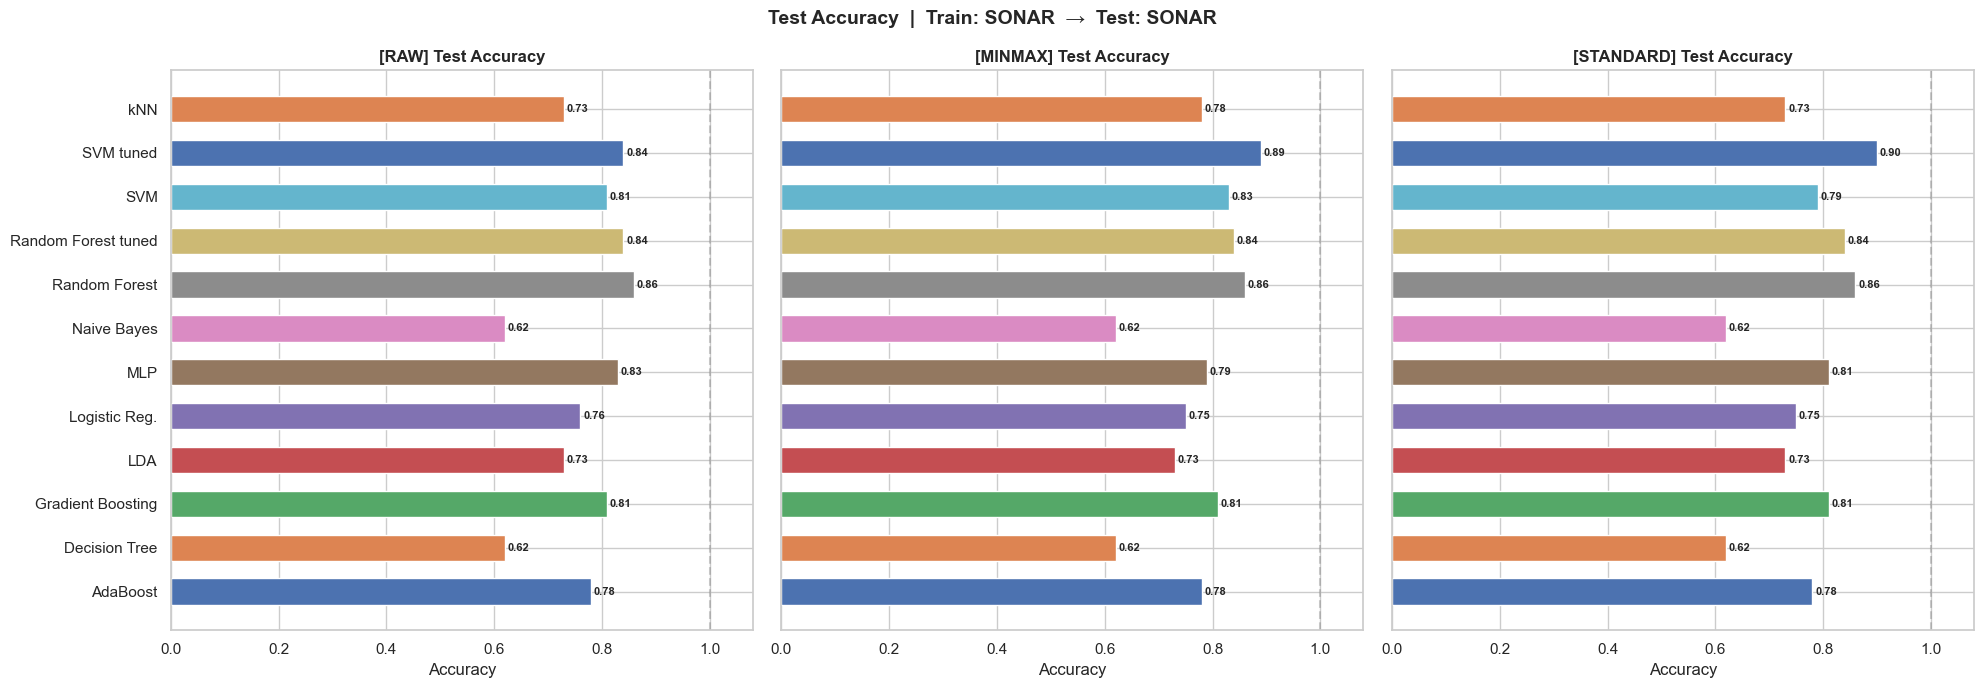

In [8]:
scalers_avail = [s for s in ['raw','minmax','standard'] if s in all_models]
fig, axes = plt.subplots(1, len(scalers_avail), figsize=(20, 7), sharey=True)
if len(scalers_avail) == 1:
    axes = [axes]
for idx, sn in enumerate(scalers_avail):
    subset = df_test[df_test['Scaler'] == sn]
    bars   = axes[idx].barh(subset['Model'], subset['Accuracy'],
                             color=COLORS[:len(subset)], edgecolor='white', height=0.6)
    axes[idx].set_title(f'[{sn.upper()}] Test Accuracy', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Accuracy')
    axes[idx].set_xlim(0.0, 1.08)
    axes[idx].axvline(x=1.0, color='gray', linestyle='--', alpha=0.4)
    for bar, row in zip(bars, subset.itertuples()):
        axes[idx].text(row.Accuracy + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{row.Accuracy:.2f}', va='center', fontsize=8, fontweight='bold')
plt.suptitle(
    f'Test Accuracy  |  Train: {TRAIN_DATA_NAME.upper()}  →  Test: {TEST_DATA_NAME.upper()}',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_accuracy.png'), bbox_inches='tight')
plt.show()

## Bước 17: Confusion Matrix – Best Model

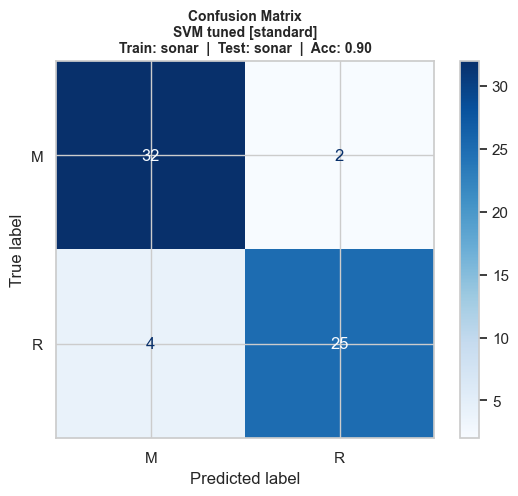


=== Classification Report ===
              precision    recall  f1-score   support

           M       0.89      0.94      0.91        34
           R       0.93      0.86      0.89        29

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



In [9]:
best_sn = best_overall['scaler']
X_test, y_test = load_test(TEST_FILES[best_sn])
y_pred  = best_overall['model'].predict(X_test)
classes = np.unique(y_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(
    f'Confusion Matrix\n{best_overall["name"]} [{best_sn}]\n'
    f'Train: {TRAIN_DATA_NAME}  |  Test: {TEST_DATA_NAME}  |  Acc: {best_overall["acc"]:.2f}',
    fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_cm.png'), bbox_inches='tight')
plt.show()
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=classes))

## Bước 18: ROC Curves

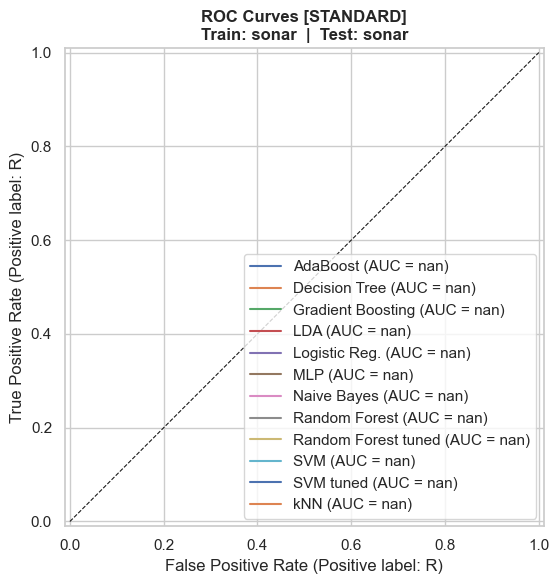

In [10]:
X_test, y_test = load_test(TEST_FILES[best_sn])
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, est in all_models[best_sn].items():
    if not hasattr(est, 'predict_proba'):
        continue
    RocCurveDisplay.from_estimator(est, X_test, y_test==pos_label, ax=ax, name=model_name)
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_title(f'ROC Curves [{best_sn.upper()}]\nTrain: {TRAIN_DATA_NAME}  |  Test: {TEST_DATA_NAME}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,
    f'{TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_plot_roc.png'), bbox_inches='tight')
plt.show()

## Bước 19: Ghi test_log.xlsx

In [11]:
df_exp_info = pd.DataFrame([{
    'Thời gian'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Train data'   : TRAIN_DATA_NAME,
    'Test data'    : TEST_DATA_NAME,
    'Best model'   : best_overall['name'],
    'Best scaler'  : best_overall['scaler'],
    'Best Test Acc': best_overall['acc'],
}])

file_exists = os.path.exists(TEST_LOG)
if file_exists:
    try:
        df_old     = pd.read_excel(TEST_LOG, sheet_name='Lich_su_chay')
        df_history = pd.concat([df_old, df_exp_info], ignore_index=True)
    except Exception:
        df_history = df_exp_info
else:
    df_history = df_exp_info

with pd.ExcelWriter(TEST_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer, sheet_name='Lich_su_chay', index=False)
    for sn in ['raw', 'minmax', 'standard']:
        subset = df_test[df_test['Scaler'] == sn].drop(columns='Scaler')
        if not subset.empty:
            subset.to_excel(writer, sheet_name=f'Test_{sn}', index=False)
    df_test.to_excel(writer, sheet_name='Test_TatCa', index=False)

label = '🆕 Tạo file mới' if not file_exists else '➕ Đã thêm lịch sử vào'
print(f'{label}: {os.path.basename(TEST_LOG)}')
print(f'\n📋 Cấu trúc file Excel:')
wb = load_workbook(TEST_LOG)
for i, sh in enumerate(wb.sheetnames):
    print(f'   Sheet {i+1}: {sh}')
wb.close()

🆕 Tạo file mới: sonar__test_sonar_log.xlsx

📋 Cấu trúc file Excel:
   Sheet 1: Lich_su_chay
   Sheet 2: Test_raw
   Sheet 3: Test_minmax
   Sheet 4: Test_standard
   Sheet 5: Test_TatCa


## Tổng kết thực nghiệm Test

In [12]:
print('=' * 65)
print('TỔNG KẾT TEST')
print('=' * 65)
print(f'\n📌 Cấu hình:')
print(f'   Model từ    : model/{TRAIN_DATA_NAME}/')
print(f'   Test trên   : {TEST_DATA_NAME}_test_*.csv')
print(f'\n🏆 Model tốt nhất:')
print(f'   Tên         : {best_overall["name"]}')
print(f'   Scaler      : {best_overall["scaler"]}')
print(f'   Test Acc    : {best_overall["acc"]:.2f}')
print(f'\n📁 File kết quả (exps_/):')
print(f'   {os.path.basename(TEST_LOG)}')
for suffix in ['plot_accuracy', 'plot_cm', 'plot_roc']:
    print(f'   {TRAIN_DATA_NAME}__test_{TEST_DATA_NAME}_{suffix}.png')
print('=' * 65)

TỔNG KẾT TEST

📌 Cấu hình:
   Model từ    : model/sonar/
   Test trên   : sonar_test_*.csv

🏆 Model tốt nhất:
   Tên         : SVM tuned
   Scaler      : standard
   Test Acc    : 0.90

📁 File kết quả (exps_/):
   sonar__test_sonar_log.xlsx
   sonar__test_sonar_plot_accuracy.png
   sonar__test_sonar_plot_cm.png
   sonar__test_sonar_plot_roc.png
